# ATDL Assignment 1 — Test the Models on Your Own Images

Upload any image(s) and see what the teacher, FP32 baseline, and ternary student each predict, side by side.

**Important caveat before you try this:** these models were trained exclusively on CIFAR-10's 10 classes --- `airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck` --- at 32x32 resolution. There is no "none of the above" / "unknown" output; whatever you upload will be forced into one of these 10 buckets, however unrelated. For results that actually mean something, use photos reasonably close to one of these categories (a car, a dog, a plane, etc.), ideally a simple, mostly-centered subject -- CIFAR-10 images have no background clutter, and real photos will look very different from what these models actually trained on, so don't be surprised if accuracy is noticeably worse than the ~95% test accuracy on real CIFAR-10 images.

**No GPU needed** -- this is just a handful of forward passes.

In [ ]:
import os, sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_DIR = "/content/drive/MyDrive/atdl"
else:
    DRIVE_DIR = "."

TEACHER_CKPT = os.path.join(DRIVE_DIR, "resnet34_cifar10_teacher_best.pth")
BASELINE_CKPT = os.path.join(DRIVE_DIR, "resnet18_cifar10_fp32_baseline_best.pth")
STUDENT_CKPT = os.path.join(DRIVE_DIR, "ternary_resnet18_kd_qat_student_best.pth")

for name, path in [("Teacher", TEACHER_CKPT), ("Baseline", BASELINE_CKPT), ("Student", STUDENT_CKPT)]:
    print(f"{name}: {'found' if os.path.exists(path) else 'MISSING'}")

Mounted at /content/drive
Teacher: found
Baseline: found
Student: found


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)
print(f"Using device: {DEVICE}")

Using device: cpu


## Embedded architectures (teacher, baseline, ternary student)

Same definitions as every earlier notebook.

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)

class ResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out); out = self.layer2(out); out = self.layer3(out); out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)

def ResNet34(num_classes=10): return ResNetCIFAR(BasicBlock, [3, 4, 6, 3], num_classes)
def ResNet18(num_classes=10): return ResNetCIFAR(BasicBlock, [2, 2, 2, 2], num_classes)


def ternary_quantize(w, per_channel=True, delta_factor=0.7):
    orig_shape = w.shape
    if per_channel:
        w_flat = w.reshape(w.size(0), -1)
        delta = delta_factor * w_flat.abs().mean(dim=1, keepdim=True)
        mask = (w_flat.abs() > delta).float()
        denom = mask.sum(dim=1, keepdim=True).clamp(min=1.0)
        alpha = (w_flat.abs() * mask).sum(dim=1, keepdim=True) / denom
        w_q = (alpha * mask * torch.sign(w_flat)).reshape(orig_shape)
        return w_q, alpha.view(-1), delta.view(-1)
    else:
        delta = delta_factor * w.abs().mean()
        mask = (w.abs() > delta).float()
        denom = mask.sum().clamp(min=1.0)
        alpha = (w.abs() * mask).sum() / denom
        w_q = alpha * mask * torch.sign(w)
        return w_q, alpha, delta

class _TernarySTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, w, delta_factor, per_channel, clip_grad, clip_value):
        w_q, _, _ = ternary_quantize(w, per_channel=per_channel, delta_factor=delta_factor)
        return w_q
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None, None, None, None

def ternary_quantize_ste(w, delta_factor=0.7, per_channel=True, clip_grad=False, clip_value=1.0):
    return _TernarySTE.apply(w, delta_factor, per_channel, clip_grad, clip_value)

class TernaryConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=False,
                 delta_factor=0.7, per_channel=True, clip_grad=False, clip_value=1.0):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_channels, in_channels, kernel_size, kernel_size))
        nn.init.kaiming_normal_(self.weight, mode="fan_out", nonlinearity="relu")
        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None
        self.stride, self.padding = stride, padding
        self.delta_factor, self.per_channel = delta_factor, per_channel
        self.clip_grad, self.clip_value = clip_grad, clip_value
    def forward(self, x):
        w_q = ternary_quantize_ste(self.weight, self.delta_factor, self.per_channel, self.clip_grad, self.clip_value)
        return F.conv2d(x, w_q, self.bias, stride=self.stride, padding=self.padding)

class TernaryLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, delta_factor=0.7,
                 per_channel=True, clip_grad=False, clip_value=1.0):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.delta_factor, self.per_channel = delta_factor, per_channel
        self.clip_grad, self.clip_value = clip_grad, clip_value
    def forward(self, x):
        w_q = ternary_quantize_ste(self.weight, self.delta_factor, self.per_channel, self.clip_grad, self.clip_value)
        return F.linear(x, w_q, self.bias)

class TernaryBasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1, ternary_kwargs=None):
        super().__init__()
        tk = ternary_kwargs or {}
        self.conv1 = TernaryConv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False, **tk)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = TernaryConv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False, **tk)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                TernaryConv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False, **tk),
                nn.BatchNorm2d(self.expansion * planes))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)

class TernaryResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, ternary_kwargs=None, ternary_fc=False):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], 1, ternary_kwargs)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], 2, ternary_kwargs)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], 2, ternary_kwargs)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], 2, ternary_kwargs)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        if ternary_fc:
            self.fc = TernaryLinear(512 * block.expansion, num_classes, **(ternary_kwargs or {}))
        else:
            self.fc = nn.Linear(512 * block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride, ternary_kwargs):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s, ternary_kwargs=ternary_kwargs))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out); out = self.layer2(out); out = self.layer3(out); out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)

def TernaryResNet18(num_classes=10, delta_factor=0.7, per_channel=True, clip_grad=False, clip_value=1.0, ternary_fc=False):
    ternary_kwargs = dict(delta_factor=delta_factor, per_channel=per_channel, clip_grad=clip_grad, clip_value=clip_value)
    return TernaryResNetCIFAR(TernaryBasicBlock, [2, 2, 2, 2], num_classes, ternary_kwargs=ternary_kwargs, ternary_fc=ternary_fc)

## Load all three models

In [ ]:
teacher = ResNet34(num_classes=10).to(DEVICE)
teacher.load_state_dict(torch.load(TEACHER_CKPT, map_location=DEVICE)["model_state_dict"])
teacher.eval()

baseline = ResNet18(num_classes=10).to(DEVICE)
baseline.load_state_dict(torch.load(BASELINE_CKPT, map_location=DEVICE)["model_state_dict"])
baseline.eval()

student = TernaryResNet18(num_classes=10, delta_factor=0.7, per_channel=True, ternary_fc=False).to(DEVICE)
student.load_state_dict(torch.load(STUDENT_CKPT, map_location=DEVICE)["model_state_dict"])
student.eval()

models = {"Teacher": teacher, "Baseline": baseline, "Student (ternary)": student}
print("All three models loaded and ready.")

All three models loaded and ready.


## Preprocessing

Every image is resized to 32x32 (the resolution these models were trained on -- fine detail from a higher-resolution photo will simply be lost/blurred by this downsampling, which is itself a major reason predictions on real photos can look worse than on real CIFAR-10 images), converted to a tensor, and normalized with the same CIFAR-10 mean/std used during training.

In [ ]:
def preprocess_image(pil_img):
    pil_img = pil_img.convert("RGB").resize((32, 32), Image.BILINEAR)
    arr = np.array(pil_img).astype(np.float32) / 255.0
    arr = (arr - np.array(CIFAR_MEAN)) / np.array(CIFAR_STD)
    tensor = torch.from_numpy(arr).permute(2, 0, 1).float().unsqueeze(0)
    return pil_img, tensor


@torch.no_grad()
def predict_all_models(tensor):
    tensor = tensor.to(DEVICE)
    results = {}
    for name, model in models.items():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        top3_idx = probs.argsort()[::-1][:3]
        results[name] = [(CLASS_NAMES[i], float(probs[i])) for i in top3_idx]
    return results

## Upload your image(s)

Run this cell, then use the file picker that appears to select one or more images from your computer. Works in Colab; if running locally instead, edit the cell below to point `image_paths` at files already on disk.

In [ ]:
import os

IN_COLAB = "google.colab" in sys.modules

pil_images = []
image_labels = []

# List of image files present in /content/
image_filenames = [
    'aeroplane.jpeg', 'horse.jpeg', 'dog (1).jpeg', 'cat.jpeg', 'frog.jpeg',
    'truck.jpeg', 'deer.jpeg', 'bird.jpeg', 'cat (1).jpeg', 'ship.jpeg', 'dog.jpeg'
]

for filename in image_filenames:
    file_path = os.path.join('/content/', filename)
    if os.path.exists(file_path):
        pil_images.append(Image.open(file_path))
        image_labels.append(filename)
    else:
        print(f"Warning: Image file not found at {file_path}")

print(f"Loaded {len(pil_images)} image(s): {image_labels}")

Loaded 11 image(s): ['aeroplane.jpeg', 'horse.jpeg', 'dog (1).jpeg', 'cat.jpeg', 'frog.jpeg', 'truck.jpeg', 'deer.jpeg', 'bird.jpeg', 'cat (1).jpeg', 'ship.jpeg', 'dog.jpeg']


## Run predictions and display results

Shows each uploaded image (both the original and the actual 32x32 downsampled version the models see), with the top-3 predicted classes and confidence from all three models underneath.


=== aeroplane.jpeg ===
  Teacher             : airplane (91.2%), frog (1.0%), deer (1.0%)
  Baseline            : airplane (92.1%), deer (1.0%), automobile (0.9%)
  Student (ternary)   : airplane (92.3%), deer (0.9%), bird (0.9%)

=== horse.jpeg ===
  Teacher             : horse (91.7%), airplane (1.0%), cat (1.0%)
  Baseline            : horse (92.0%), deer (1.0%), cat (0.9%)
  Student (ternary)   : horse (92.8%), bird (0.8%), ship (0.8%)

=== dog (1).jpeg ===
  Teacher             : dog (91.5%), truck (1.0%), frog (1.0%)
  Baseline            : dog (90.5%), horse (1.2%), automobile (1.2%)
  Student (ternary)   : dog (92.2%), cat (1.1%), truck (0.9%)

=== cat.jpeg ===
  Teacher             : cat (92.3%), dog (0.9%), deer (0.9%)
  Baseline            : cat (92.0%), deer (1.0%), automobile (0.9%)
  Student (ternary)   : cat (91.8%), automobile (1.0%), truck (1.0%)

=== frog.jpeg ===
  Teacher             : frog (91.3%), airplane (1.0%), horse (1.0%)
  Baseline            : frog (93.2%)

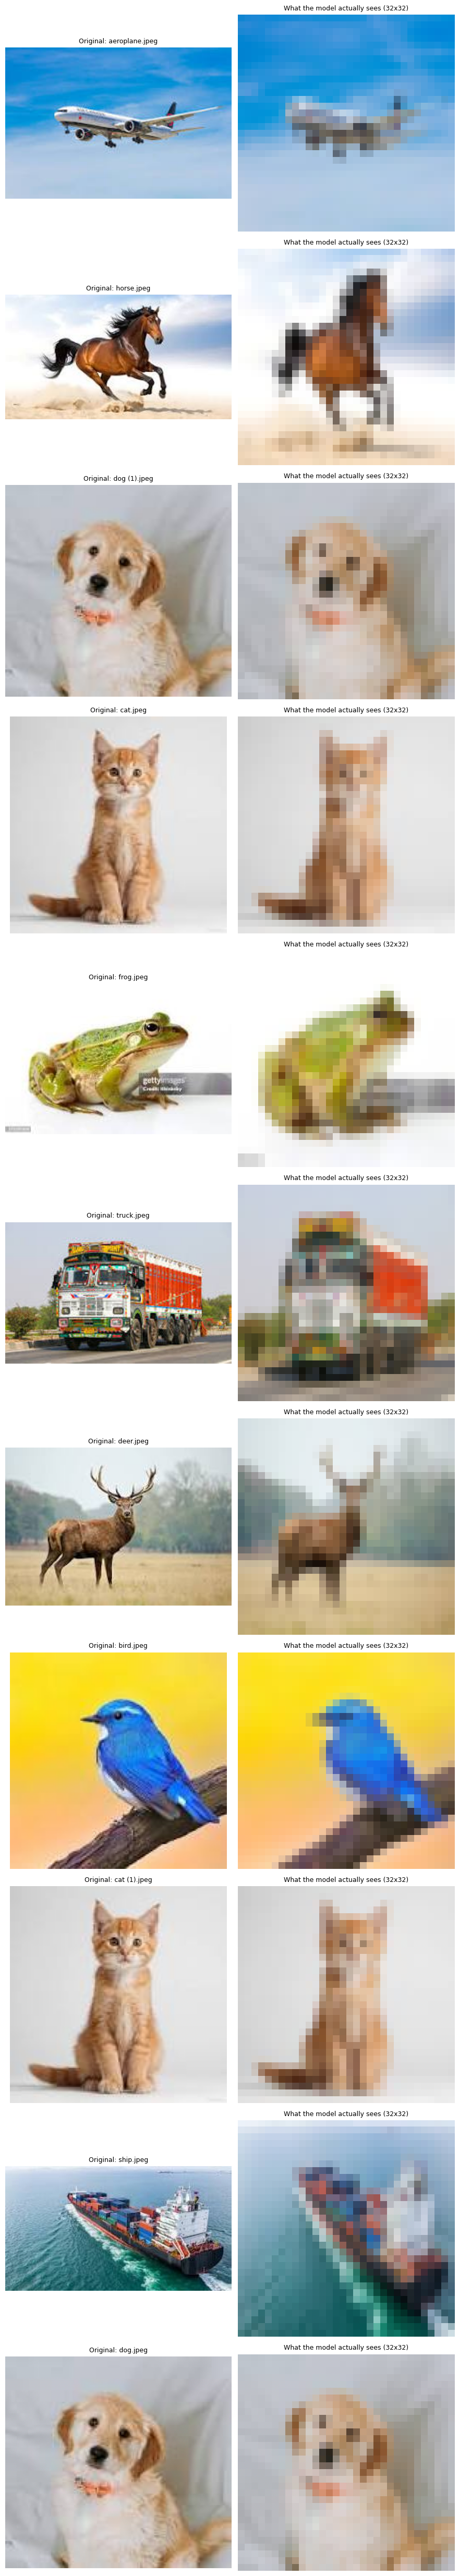

In [ ]:
n = len(pil_images)
if n == 0:
    print("No images uploaded -- run the upload cell above first.")
else:
    fig, axes = plt.subplots(n, 2, figsize=(9, 4.5 * n), squeeze=False)

    for row, (pil_img, label) in enumerate(zip(pil_images, image_labels)):
        resized_img, tensor = preprocess_image(pil_img)
        results = predict_all_models(tensor)

        axes[row, 0].imshow(pil_img)
        axes[row, 0].set_title(f"Original: {label}", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(resized_img)
        axes[row, 1].set_title("What the model actually sees (32x32)", fontsize=9)
        axes[row, 1].axis("off")

        print(f"\n=== {label} ===")
        for model_name, top3 in results.items():
            preds_str = ", ".join([f"{cls} ({prob*100:.1f}%)" for cls, prob in top3])
            print(f"  {model_name:20s}: {preds_str}")

    plt.tight_layout()
    plt.show()

## Interpreting the results

- If all three models agree and are confident, that's a strong, unambiguous prediction.
- If the **student disagrees with the teacher** on an out-of-distribution photo like this, that's not necessarily evidence of a problem with the student specifically -- all three models are being pushed outside the data distribution they were trained on (real photos vs. CIFAR-10's specific 32x32 style), so disagreement here says less about compression quality than the earlier confusion-matrix/per-class-accuracy analysis on the actual CIFAR-10 test set does.
- For a report-worthy qualitative figure, real CIFAR-10 test images (as in the `sample_predictions.png` from the general-visualizations notebook) are more representative of true model behavior than arbitrary uploaded photos; this notebook is better suited for your own exploration/intuition-building than for a claim in the report itself.